In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv ("../data/train.csv")

# Display first rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
 df.shape

(9800, 18)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Data Quality and Ethical Considerations

Missing values were identified in the Postal Code column (11 records). While minimal, this highlights the importance of data completeness.

Incomplete data may affect the reliability of location-based insights and should be considered when interpreting results.

This will be further discussed in the ethics section of the project.

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [8]:
df["Sales"].sum()

2261536.7827000003

### Total Sales

The dataset generated a total revenue of approximately **2.26 million**, indicating strong overall sales performance across all regions and product categories.

In [9]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

### Sales by Region

The West region generated the highest sales, followed closely by the East region. 

The Central region showed moderate performance, while the South region recorded the lowest sales.

This suggests that sales performance varies significantly across regions, which may be influenced by factors such as customer demand, regional marketing strategies, or population distribution.

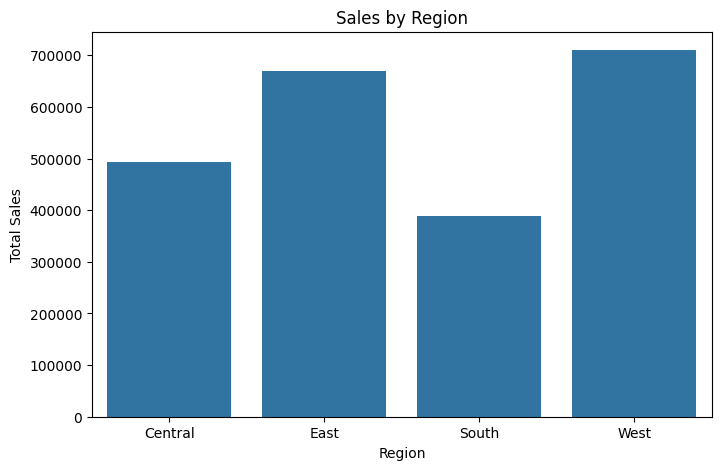

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

region_sales = df.groupby("Region")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x="Region", y="Sales")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [10]:
df.groupby("Segment")["Sales"].sum()

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

### Sales by Segment

The Consumer segment generated the highest sales, significantly outperforming both the Corporate and Home Office segments.

Corporate customers contributed a moderate portion of total revenue, while the Home Office segment recorded the lowest sales.

This indicates that individual consumers are the primary drivers of revenue, suggesting a strong B2C market presence.

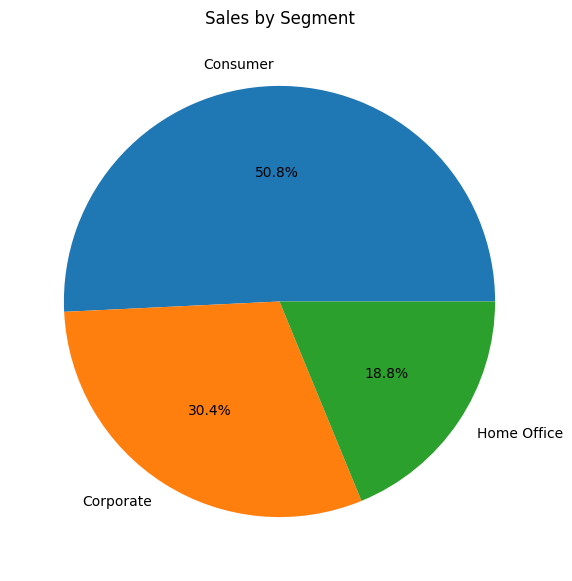

In [18]:
segment_sales = df.groupby("Segment")["Sales"].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
segment_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Segment")
plt.ylabel("")
plt.show()

In [11]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

### Sales by Category

Technology generated the highest sales among all categories, followed by Furniture and Office Supplies.

While all categories contributed significantly to overall revenue, the strong performance of Technology suggests higher demand or higher-value products within this category.

This insight could be useful for prioritising inventory, marketing, and future business strategy.

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [14]:
sales_trend = df.groupby("Order Date")["Sales"].sum()

sales_trend.head()

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64

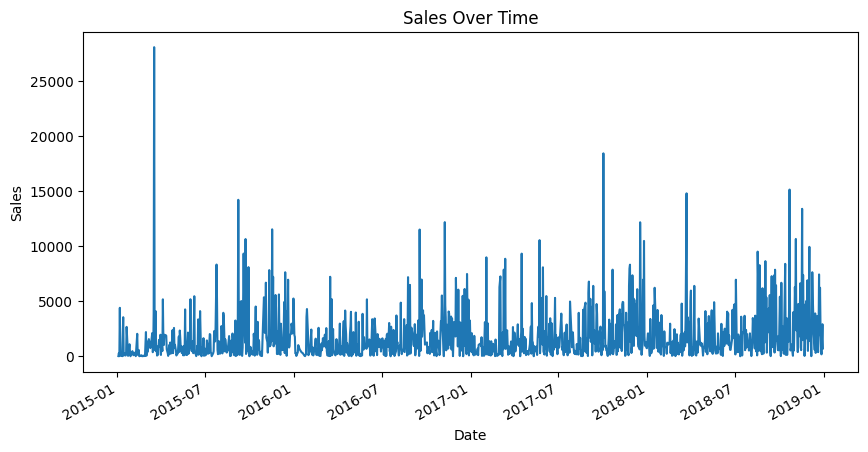

In [15]:
import matplotlib.pyplot as plt

sales_trend.plot(figsize=(10,5))
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Daily Sales Trend Observation

The daily sales trend appears highly volatile, with significant fluctuations and occasional spikes.

This level of variability makes it difficult to identify clear patterns or trends, indicating that daily data may be too granular for meaningful business insights.

To improve interpretability, the data will be aggregated at a monthly level.

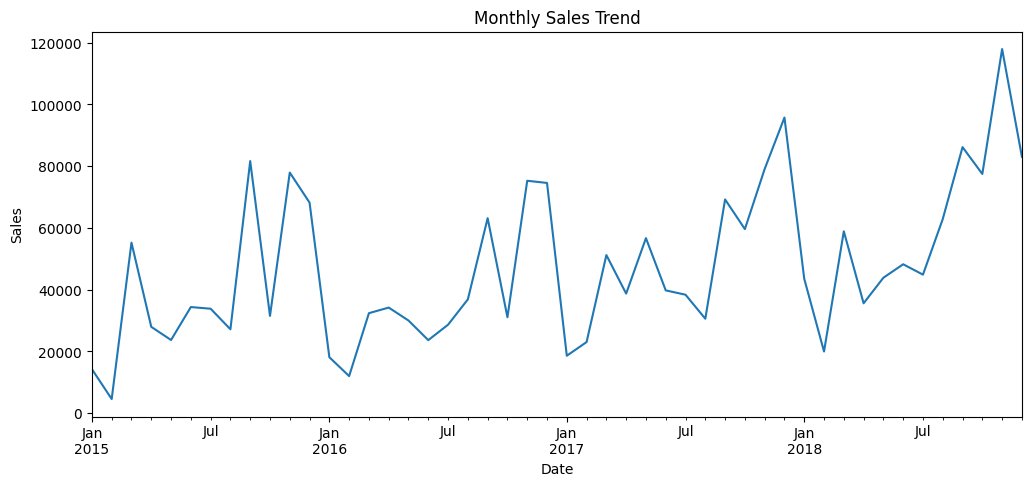

In [16]:
monthly_sales = df.resample("M", on="Order Date")["Sales"].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Monthly Sales Trend Analysis

The monthly sales trend reveals a clear upward trajectory over time, indicating overall business growth.

Although there are fluctuations between months, the general pattern shows increasing sales, particularly in the later years of the dataset.

This suggests improving business performance, potential expansion, or increased customer demand over time. Seasonal variations may also be present, with certain months showing higher peaks than others.

### Distribution of Sales

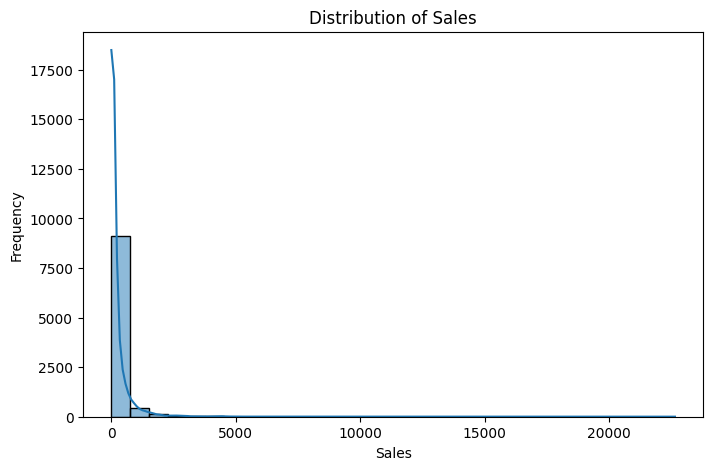

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most sales transactions are concentrated at lower values, while a small number of transactions have significantly higher sales. This indicates a right-skewed distribution, where a few high-value sales contribute disproportionately to total revenue.